Source Data: https://www.kaggle.com/datasets/jakeshbohaju/brain-tumor

# **1. Import Library**

In [77]:
# Library utama
import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# **2. Load Dataset dari Google Drive**

In [78]:
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/GoogleColab_ComputerVision/Tugas2/Dataset/Brain_Tumor.csv")

# Preview data
print(df.head())
print(df.info())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
    Image  Class      Mean     Variance  Standard Deviation   Entropy  \
0  Image1      0  6.535339   619.587845           24.891522  0.109059   
1  Image2      0  8.749969   805.957634           28.389393  0.266538   
2  Image3      1  7.341095  1143.808219           33.820234  0.001467   
3  Image4      1  5.958145   959.711985           30.979219  0.001477   
4  Image5      0  7.315231   729.540579           27.010009  0.146761   

   Skewness   Kurtosis    Contrast    Energy       ASM  Homogeneity  \
0  4.276477  18.900575   98.613971  0.293314  0.086033     0.530941   
1  3.718116  14.464618   63.858816  0.475051  0.225674     0.651352   
2  5.061750  26.479563   81.867206  0.031917  0.001019     0.268275   
3  5.677977  33.428845  151.229741  0.032024  0.001026     0.243851   
4  4.283221  19.079108  174.988756  0.343849  0.118232     0.501140   

   Di

# **3. Cek Missing Value**

In [79]:
print(df.isnull().sum())

Image                 0
Class                 0
Mean                  0
Variance              0
Standard Deviation    0
Entropy               0
Skewness              0
Kurtosis              0
Contrast              0
Energy                0
ASM                   0
Homogeneity           0
Dissimilarity         0
Correlation           0
Coarseness            0
dtype: int64


# **4. EDA (Exploratory Data Analysis)**

             Class         Mean     Variance  Standard Deviation      Entropy  \
count  3762.000000  3762.000000  3762.000000         3762.000000  3762.000000   
mean      0.447368     9.488890   711.101063           25.182271     0.073603   
std       0.497288     5.728022   467.466896            8.773526     0.070269   
min       0.000000     0.078659     3.145628            1.773592     0.000882   
25%       0.000000     4.982395   363.225459           19.058475     0.006856   
50%       0.000000     8.477531   622.580417           24.951560     0.066628   
75%       1.000000    13.212723   966.954319           31.095889     0.113284   
max       1.000000    33.239975  2910.581879           53.949809     0.394539   

          Skewness     Kurtosis     Contrast       Energy          ASM  \
count  3762.000000  3762.000000  3762.000000  3762.000000  3762.000000   
mean      4.102727    24.389071   127.961459     0.204705     0.058632   
std       2.560940    56.434747   109.499601    

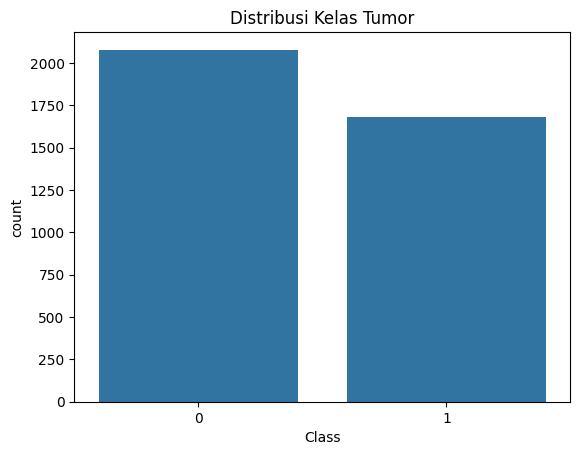

In [80]:
# Statistik dasar
print(df.describe())

# Distribusi target
sns.countplot(x=df['Class'])
plt.title("Distribusi Kelas Tumor")
plt.show()

Berdasarkan grafik distribusi kelas tumor, terlihat bahwa jumlah data pada kelas 0 sedikit lebih banyak dibandingkan kelas 1. Kelas 0 memiliki sekitar 2000+ data, sedangkan kelas 1 berada di kisaran 1600–1700 data.

Dari sini bisa disimpulkan kalau dataset yang digunakan cukup seimbang, walaupun tidak benar-benar sama jumlahnya. Perbedaan jumlah ini masih tergolong wajar dan tidak terlalu ekstrem, sehingga model masih bisa belajar dengan baik tanpa terlalu bias ke salah satu kelas.

Dengan kondisi seperti ini, metode yang digunakan (Random Forest) tetap bisa bekerja secara optimal karena tidak terlalu terpengaruh oleh ketidakseimbangan data. Jadi, model tidak akan condong hanya memprediksi satu kelas saja.

# **5. Visualisasi Korelasi**

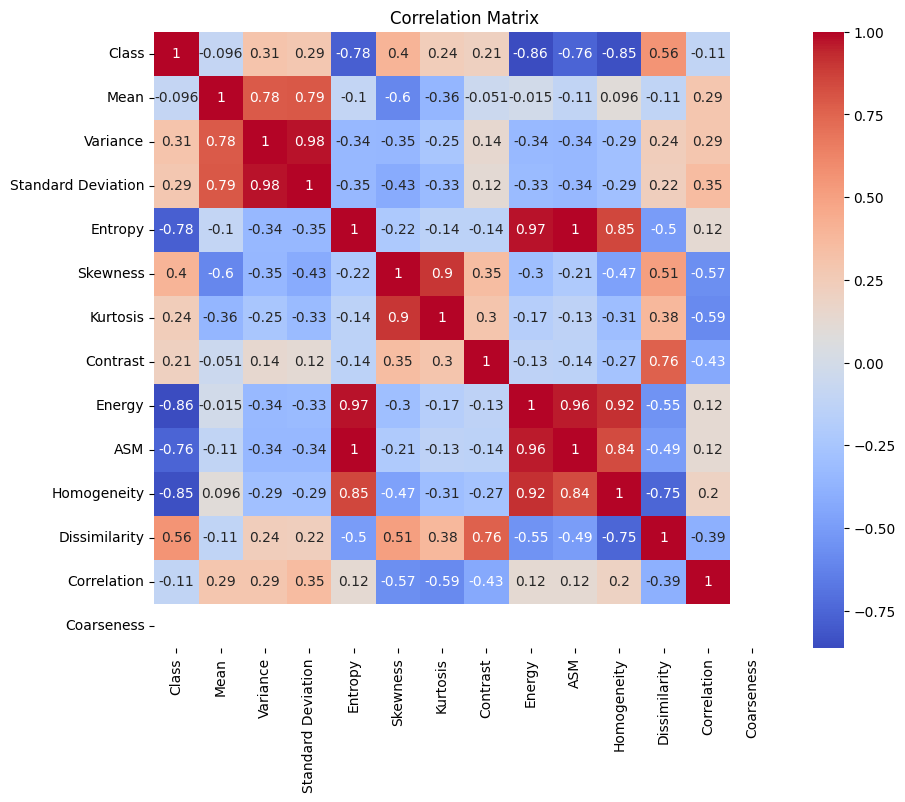

In [81]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop('Image', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Dari heatmap korelasi, terlihat hubungan antar fitur dan juga hubungannya dengan variabel target (Class).

Beberapa hal yang bisa diperhatikan:

*   Fitur seperti Energy, Entropy, ASM, dan Homogeneity memiliki korelasi yang cukup tinggi terhadap kelas, baik positif maupun negatif.
*   Energy dan ASM memiliki korelasi negatif yang cukup kuat terhadap Class
*   Entropy memiliki korelasi positif yang cukup tinggi terhadap Class




Ini menunjukkan bahwa fitur-fitur tersebut cukup berpengaruh dalam menentukan apakah suatu citra termasuk tumor atau tidak.

Selain itu, terlihat juga bahwa beberapa fitur saling berkorelasi tinggi satu sama lain, seperti:

Variance dengan Standard Deviation (≈ 0.98)
Energy dengan ASM (≈ 0.96)

Hal ini menandakan adanya redundansi fitur, yaitu beberapa fitur membawa informasi yang hampir sama. Walaupun begitu, pada metode Random Forest hal ini tidak terlalu menjadi masalah karena algoritma ini mampu menangani fitur yang saling berkorelasi.

# **6. Preprocessing (Encoding & Split)**

In [82]:
# Misal target = 'Class'
X = df.drop(['Class', 'Image'], axis=1)
y = df['Class']

# Encoding label kalau string
le = LabelEncoder()
y = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3009, 13)
Test: (753, 13)


# **7. Normalisasi Data**

In [83]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **8. Training Model Random Forest**

In [84]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# **9. Prediksi**

In [85]:
y_pred = model.predict(X_test)

# **10. Evaluasi Model**

Accuracy: 0.9840637450199203


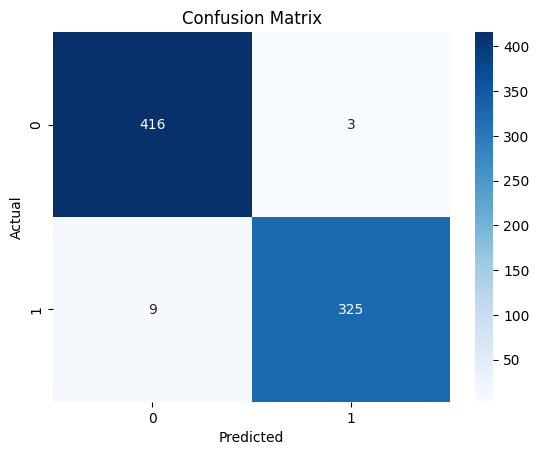

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       419
           1       0.99      0.97      0.98       334

    accuracy                           0.98       753
   macro avg       0.98      0.98      0.98       753
weighted avg       0.98      0.98      0.98       753



In [86]:
# Akurasi
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

Dari confusion matrix, didapatkan hasil sebagai berikut:


*   Prediksi benar untuk kelas 0: 416 data
*   Prediksi benar untuk kelas 1: 325 data
*   False Positive: 3 data
*   False Negative: 9 data

Dari hasil tersebut terlihat bahwa jumlah kesalahan prediksi sangat kecil dibandingkan total data. Ini menunjukkan bahwa model memiliki performa yang sangat baik dalam melakukan klasifikasi.

Selain itu, model sedikit lebih sering salah pada kelas 1 (tumor), yaitu sebanyak 9 data. Namun secara keseluruhan, akurasi tetap tinggi karena jumlah prediksi benar jauh lebih banyak

Hal ini menandakan bahwa model Random Forest mampu membedakan kedua kelas dengan cukup akurat.

# **11. Feature Importance**

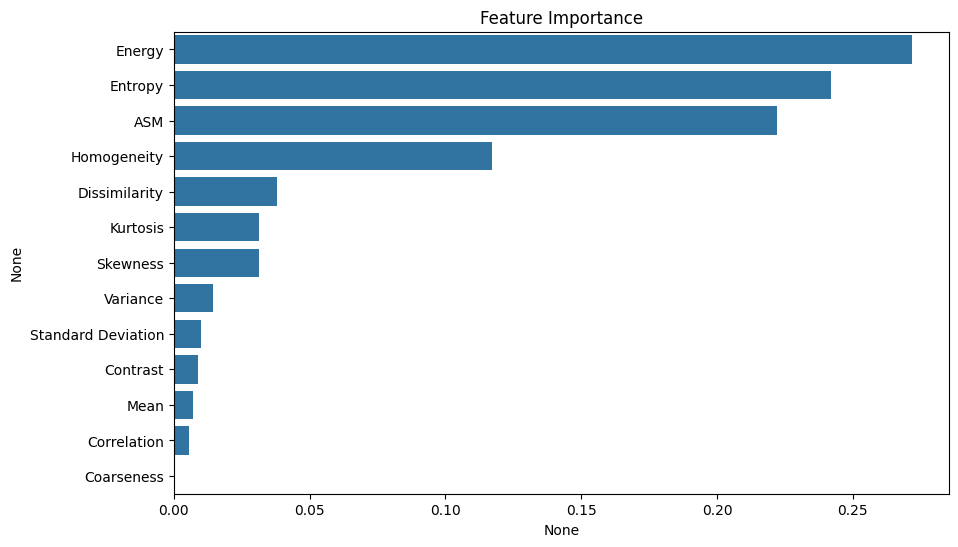

In [87]:
importances = model.feature_importances_

feat_names = X.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title("Feature Importance")
plt.show()

Berdasarkan grafik feature importance, terlihat bahwa fitur yang paling berpengaruh dalam model adalah Energy, diikuti oleh Entropy, ASM, dan Homogeneity. Keempat fitur tersebut memiliki nilai kontribusi yang jauh lebih tinggi dibandingkan fitur lainnya, sehingga dapat dikatakan sebagai faktor utama yang digunakan model dalam proses pengambilan keputusan.

Sementara itu, fitur seperti Mean, Correlation, dan Coarseness memiliki pengaruh yang relatif kecil terhadap hasil prediksi. Hal ini menunjukkan bahwa tidak semua fitur memiliki peran yang signifikan dalam membedakan antara citra tumor dan non-tumor.

Dari hasil tersebut dapat disimpulkan bahwa model Random Forest cenderung lebih mengandalkan fitur-fitur yang berkaitan dengan tekstur citra, terutama yang berhubungan dengan distribusi intensitas dan pola permukaan. Temuan ini juga sejalan dengan hasil analisis pada heatmap korelasi sebelumnya, di mana fitur-fitur seperti Energy, Entropy, ASM, dan Homogeneity menunjukkan hubungan yang cukup kuat terhadap variabel kelas.